# Study of lyapunov exponents in IFS and AIFS

This notebook aims to study the chaotic behaviour of AIFS, in order to assess whether it would be usable for rare events algorithms. Thus reducing drastically the computing time needed to run them.

The data used is the following:
- IFS Ensemble simulation, each time with a control run and 50 perturbed ensemble predictions.
- AIFS Ensemble simulation, each time with a control run and 50 perturbed ensemble predictions. Note : The AIFS-Diffusion model is used for these outputs by ECMWF, the viability of the AIFS-Deterministic model to be chaotic will be studied too. This notebook is a start until I get access to Jean-Zay GPU cluster to run my own experiments.

The operational IFS EPS samples initial uncertainty using perturbations from an ensemble of data
assimilations (EDA) and perturbations constructed from the leading singular vectors. [From the official documentation](https://www.ecmwf.int/en/elibrary/81627-ifs-documentation-cy49r1-part-v-ensemble-prediction-system)

## Helper functions and packages

In [1]:
# functions

from ensemble_chaos_tools import EnsembleChaos
import xarray as xr
import glob

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format="jpeg"

In [2]:
france_latitude_bnd = slice(42, 51)
france_longitude_bnd = slice(-5, 8)
paris_latitude = 49
paris_longitude = 2.5

bc_latitude_bnd = slice(48, 60)
bc_longitude_bnd = slice(-139, -114)
lytton_latitude = 50.23
lytton_longitude = -121.58

## Import data

In [3]:
args_import_xr_grib = {"engine": "cfgrib", "decode_timedelta": True}

In [4]:
file_cf_20190723 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2019-07-23.grib"
file_cf_20200724 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2020-07-24.grib"
file_cf_20220706 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2022-07-06.grib"
file_cf_20150622 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2015-06-22.grib"
file_cf_20170621 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2017-06-21.grib"
file_cf_20210617 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-17.grib"  # britain columbia
)
file_cf_20210614 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-14.grib"  # britain columbia
)
file_cf_20250801 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2025-08-01.grib"
file_cf_20251222 = "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2025-12-22.grib"
file_cf_20210627 = (
    "/homedata/pchevali/ens_forecast/tigge_cf_t2m_2021-06-27.grib"  # britain columbia
)


file_pf_20190723 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2019-07-23.grib"
file_pf_20200724 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2020-07-24.grib"
file_pf_20220706 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2022-07-06.grib"
file_pf_20150622 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2015-06-22.grib"
file_pf_20170621 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2017-06-21.grib"
file_pf_20210617 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-17.grib"  # britain columbia
)
file_pf_20210614 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-14.grib"  # britain columbia
)
file_pf_20250801 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2025-08-01.grib"
file_pf_20251222 = "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2025-12-22.grib"
file_pf_20210627 = (
    "/homedata/pchevali/ens_forecast/tigge_pf_t2m_2021-06-27.grib"  # britain columbia
)


cf_20150622 = xr.open_dataset(file_cf_20150622, **args_import_xr_grib)
cf_20170621 = xr.open_dataset(file_cf_20170621, **args_import_xr_grib)
cf_20190723 = xr.open_dataset(file_cf_20190723, **args_import_xr_grib)
cf_20200724 = xr.open_dataset(file_cf_20200724, **args_import_xr_grib)
cf_20210614 = xr.open_dataset(file_cf_20210614, **args_import_xr_grib)
cf_20210617 = xr.open_dataset(file_cf_20210617, **args_import_xr_grib)
cf_20220706 = xr.open_dataset(file_cf_20220706, **args_import_xr_grib)
cf_20250801 = xr.open_dataset(file_cf_20250801, **args_import_xr_grib)
cf_20251222 = xr.open_dataset(file_cf_20251222, **args_import_xr_grib)
cf_20210627 = xr.open_dataset(file_cf_20210627, **args_import_xr_grib)


pf_20150622 = xr.open_dataset(file_pf_20150622, **args_import_xr_grib)
pf_20170621 = xr.open_dataset(file_pf_20170621, **args_import_xr_grib)
pf_20190723 = xr.open_dataset(file_pf_20190723, **args_import_xr_grib)
pf_20200724 = xr.open_dataset(file_pf_20200724, **args_import_xr_grib)
pf_20210614 = xr.open_dataset(file_pf_20210614, **args_import_xr_grib)
pf_20210617 = xr.open_dataset(file_pf_20210617, **args_import_xr_grib)
pf_20220706 = xr.open_dataset(file_pf_20220706, **args_import_xr_grib)
pf_20250801 = xr.open_dataset(file_pf_20250801, **args_import_xr_grib)
pf_20251222 = xr.open_dataset(file_pf_20251222, **args_import_xr_grib)
pf_20210627 = xr.open_dataset(file_pf_20210627, **args_import_xr_grib)

In [5]:
pf_aifs_cold_spell_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_pf_20251222.nc", decode_timedelta=True
)
pf_aifs_heat_august_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_pf_20250801.nc", decode_timedelta=True
)
cf_aifs_cold_spell_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_cf_20251222.nc", decode_timedelta=True
).assign_coords(number=0)
cf_aifs_heat_august_2025 = xr.open_dataset(
    "/homedata/pchevali/ens_forecast/aifs_cf_20250801.nc", decode_timedelta=True
).assign_coords(number=0)

Creating the objects

In [6]:
chaos_ifs_20150622 = EnsembleChaos(cf_20150622, pf_20150622)
chaos_ifs_20170621 = EnsembleChaos(cf_20170621, pf_20170621)
chaos_ifs_20190723 = EnsembleChaos(cf_20190723, pf_20190723)
chaos_ifs_20200724 = EnsembleChaos(cf_20200724, pf_20200724)
chaos_ifs_20220706 = EnsembleChaos(cf_20220706, pf_20220706)
chaos_ifs_heat_august_2025 = EnsembleChaos(cf_20250801, pf_20250801)
chaos_ifs_cold_spell_2025 = EnsembleChaos(cf_20251222, pf_20251222)
chaos_ifs_20210614 = EnsembleChaos(cf_20210614, pf_20210614) #bc
chaos_ifs_20210617 = EnsembleChaos(cf_20210617, pf_20210617) #bc
chaos_ifs_20210627 = EnsembleChaos(cf_20210627, pf_20210627) #bc

chaos_aifs_cold_spell_2025 = EnsembleChaos(cf_aifs_cold_spell_2025, pf_aifs_cold_spell_2025)
chaos_aifs_heat_august_2025 = EnsembleChaos(cf_aifs_heat_august_2025, pf_aifs_heat_august_2025)

## Plot trajectories

### At a single point

#### Only IFS

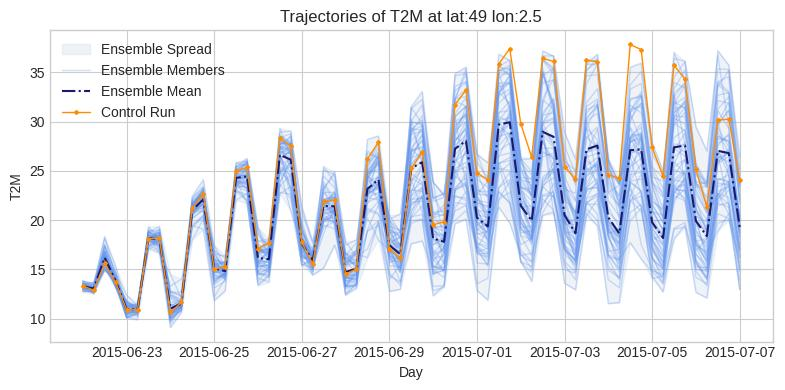

In [7]:
chaos_ifs_20150622.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

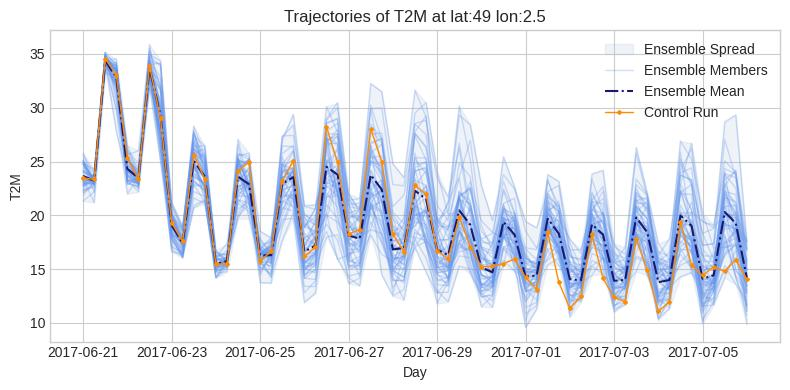

In [8]:
chaos_ifs_20170621.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

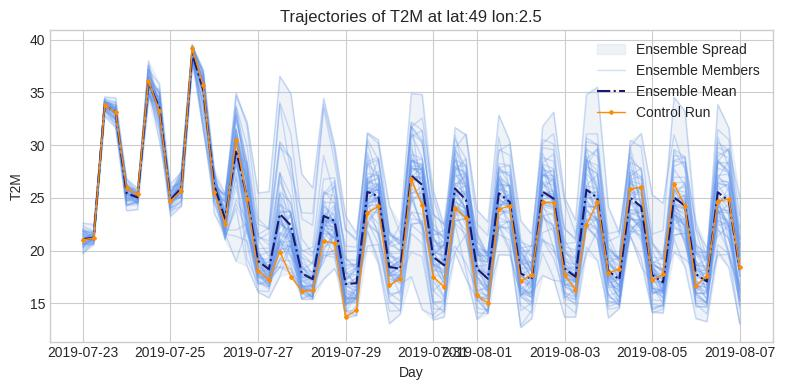

In [9]:
chaos_ifs_20190723.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

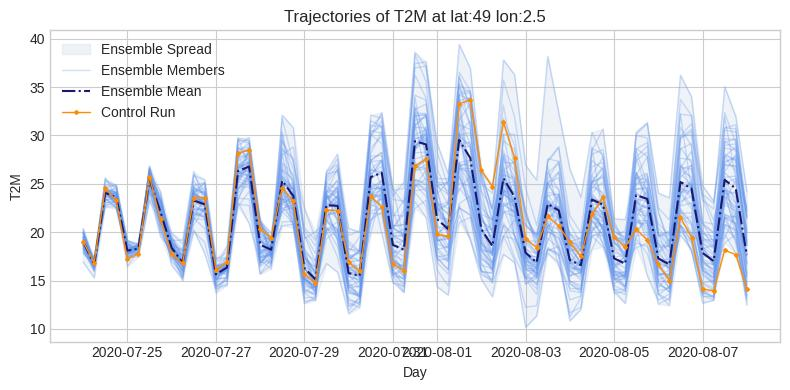

In [10]:
chaos_ifs_20200724.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

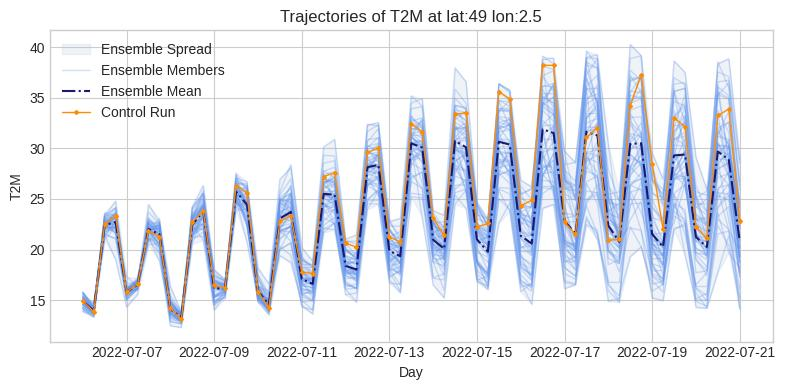

In [11]:
chaos_ifs_20220706.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

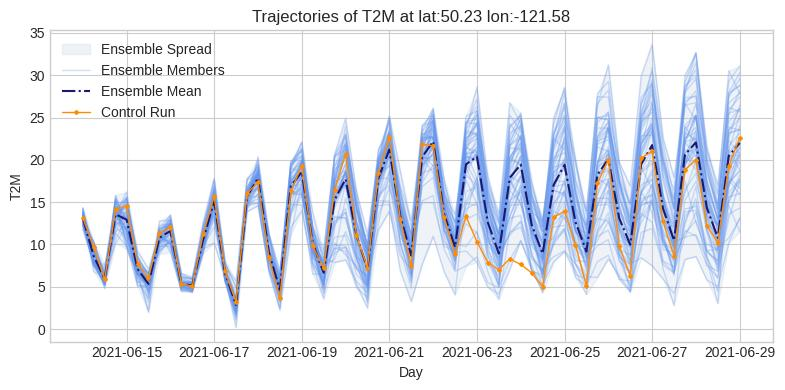

In [12]:
chaos_ifs_20210614.plot_trajectories_on_single_point(lytton_latitude,lytton_longitude)

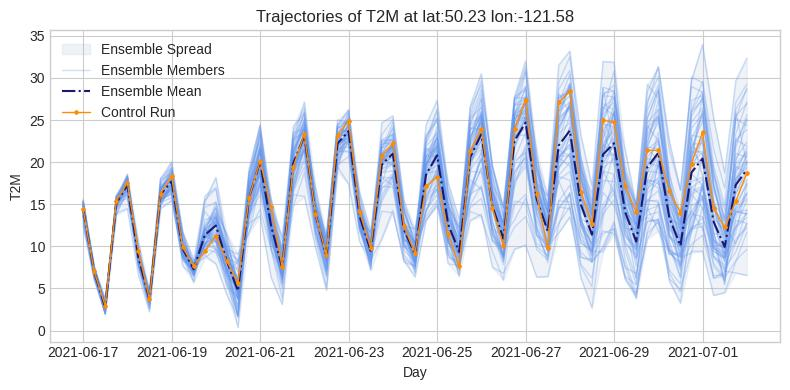

In [13]:
chaos_ifs_20210617.plot_trajectories_on_single_point(lytton_latitude,lytton_longitude)

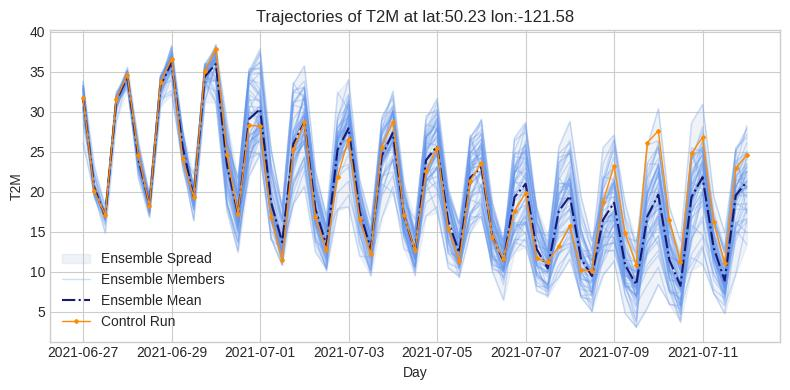

In [14]:
chaos_ifs_20210627.plot_trajectories_on_single_point(lytton_latitude,lytton_longitude)

#### IFS and AIFS

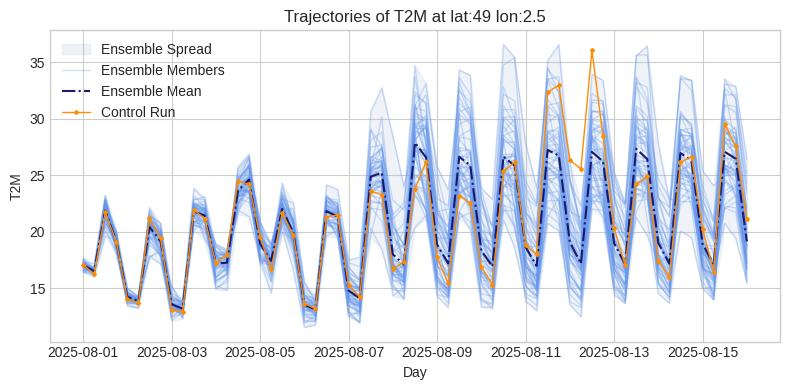

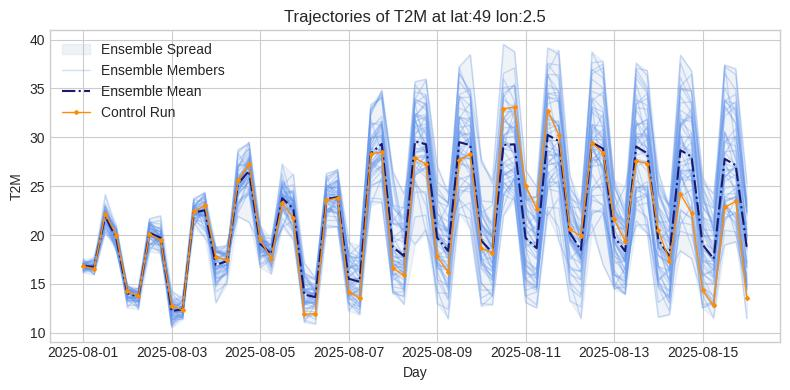

In [15]:
chaos_ifs_heat_august_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude)
chaos_aifs_heat_august_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

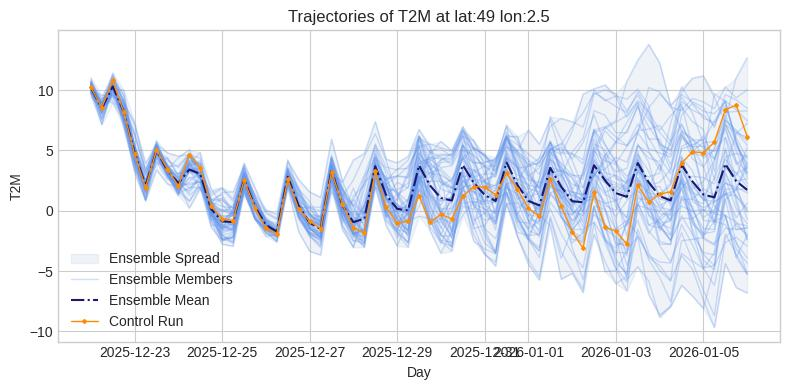

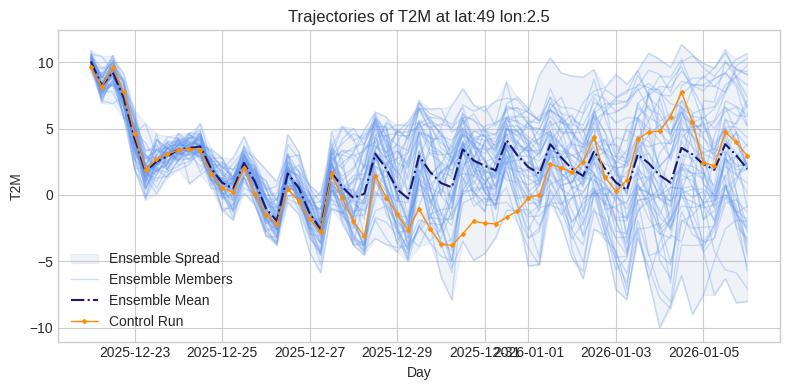

In [16]:
chaos_ifs_cold_spell_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude)
chaos_aifs_cold_spell_2025.plot_trajectories_on_single_point(paris_latitude,paris_longitude)

### Over an area

#### Only IFS

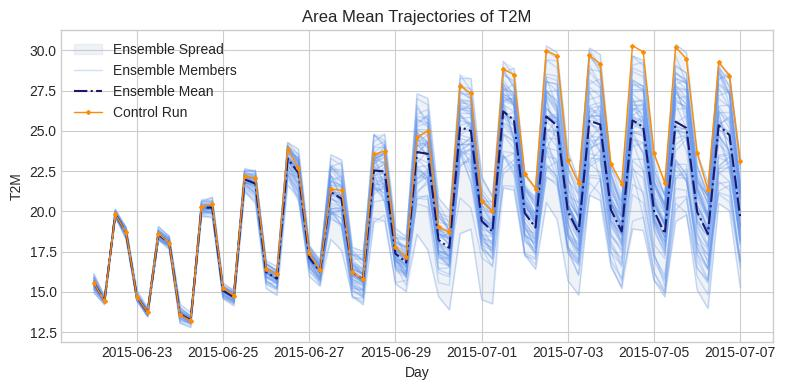

In [17]:
chaos_ifs_20150622.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)

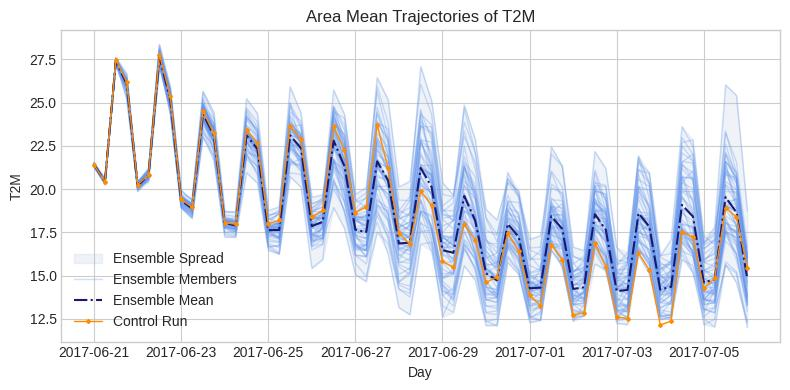

In [18]:
chaos_ifs_20170621.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)

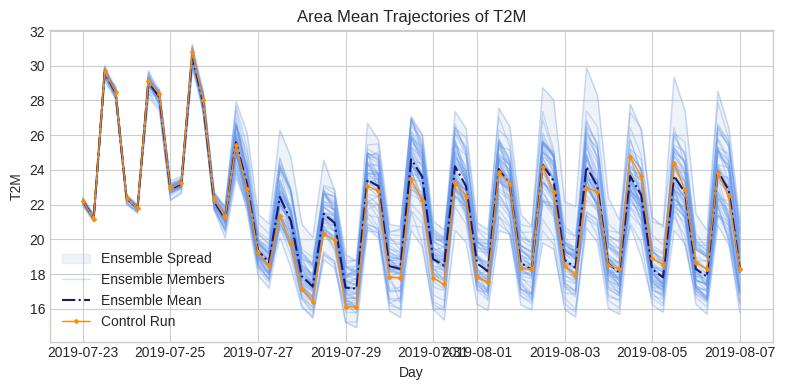

In [19]:
chaos_ifs_20190723.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)

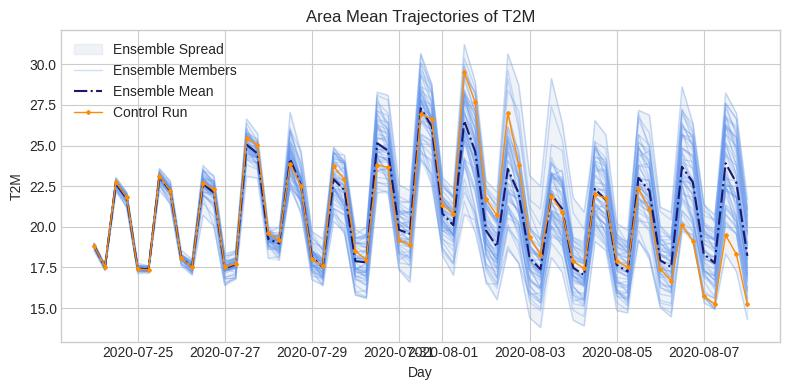

In [20]:
chaos_ifs_20200724.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)

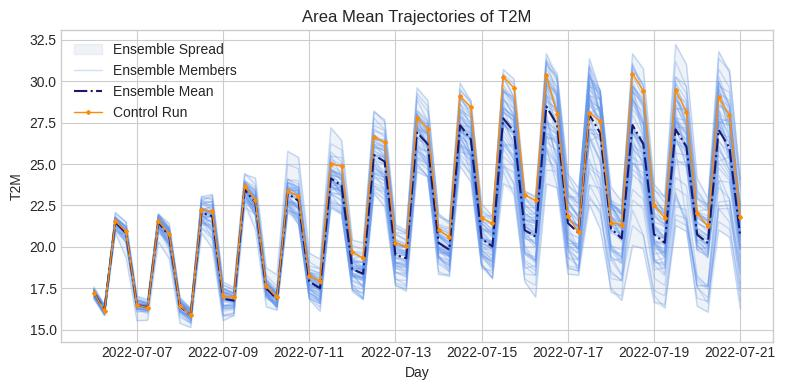

In [21]:
chaos_ifs_20220706.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)

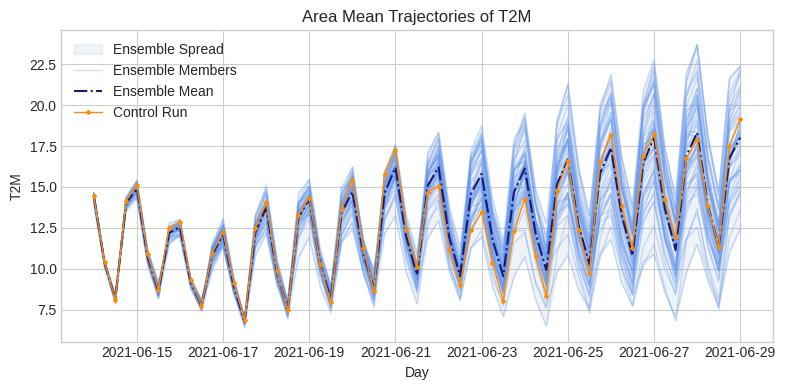

In [22]:
chaos_ifs_20210614.plot_trajectories_on_area_mean(bc_latitude_bnd,bc_longitude_bnd)

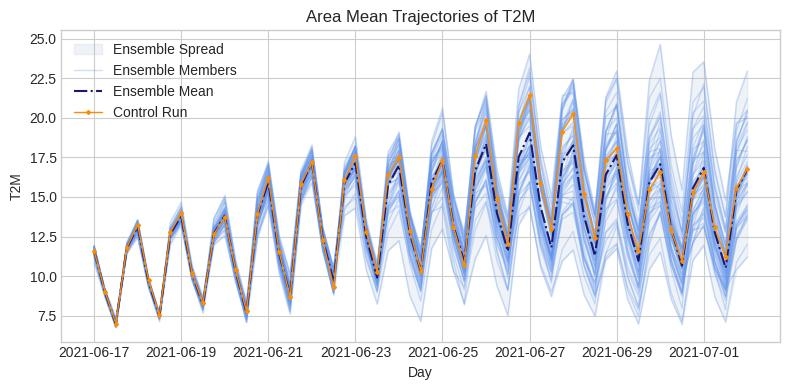

In [23]:
chaos_ifs_20210617.plot_trajectories_on_area_mean(bc_latitude_bnd,bc_longitude_bnd)

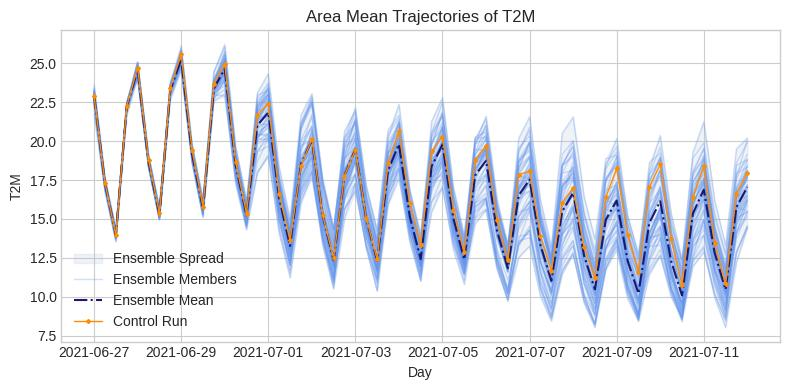

In [24]:
chaos_ifs_20210627.plot_trajectories_on_area_mean(bc_latitude_bnd,bc_longitude_bnd)

#### IFS and AIFS

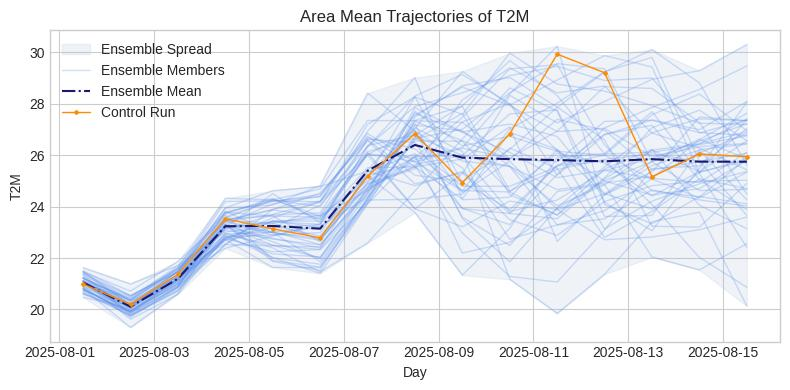

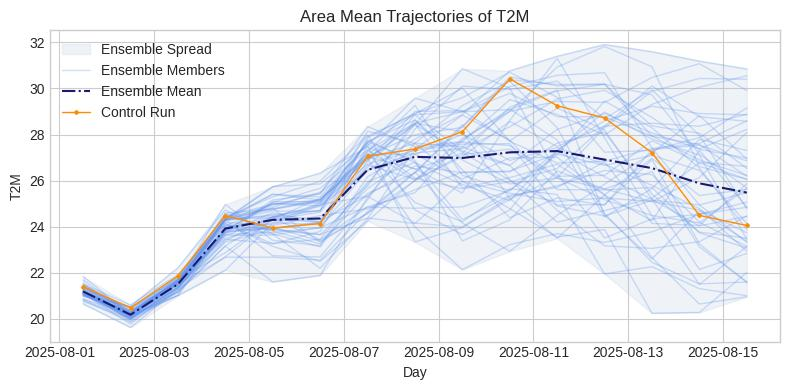

In [25]:
chaos_ifs_heat_august_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])
chaos_aifs_heat_august_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd,[12])

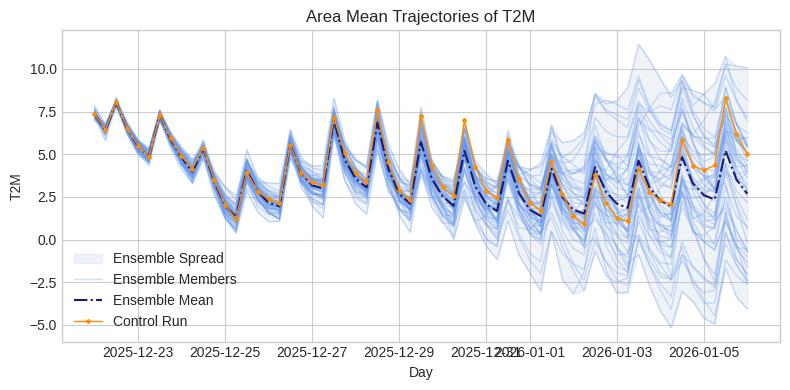

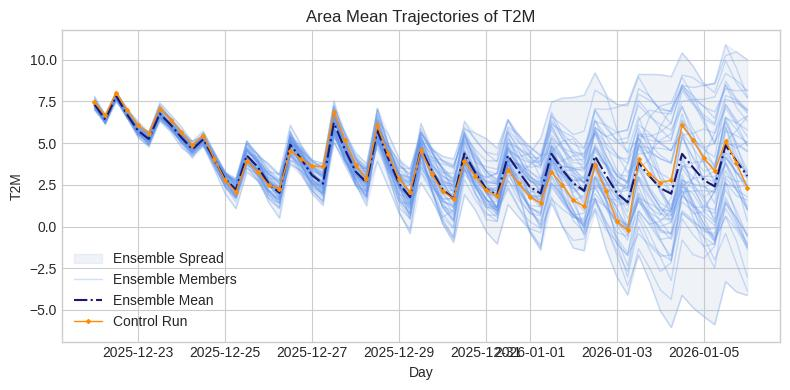

In [26]:
chaos_ifs_cold_spell_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)
chaos_aifs_cold_spell_2025.plot_trajectories_on_area_mean(france_latitude_bnd,france_longitude_bnd)

## Compute Lyapunov Exponents

### At a single point

#### Only IFS

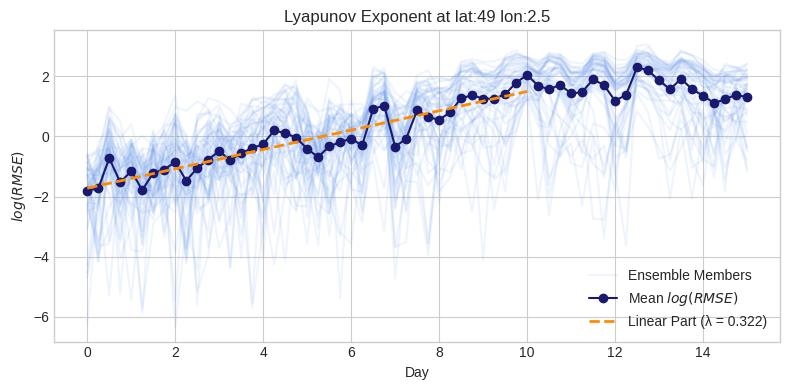

Estimated Lyapunov Exponent (λ): 0.322 days^-1


In [27]:
chaos_ifs_20150622.lyapunov_single_point(paris_latitude,paris_longitude)

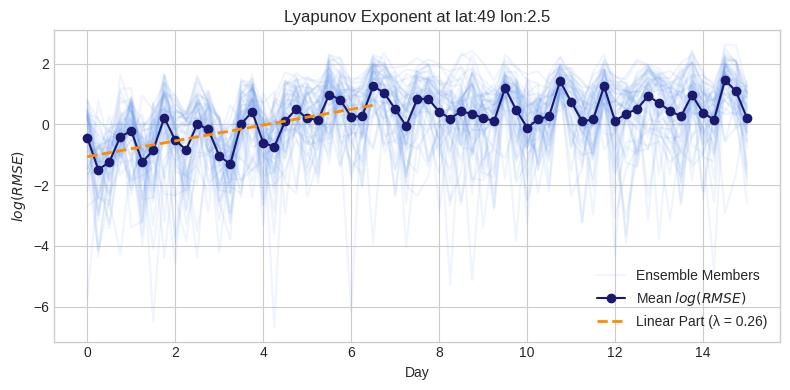

Estimated Lyapunov Exponent (λ): 0.26 days^-1


In [28]:
chaos_ifs_20170621.lyapunov_single_point(paris_latitude,paris_longitude)

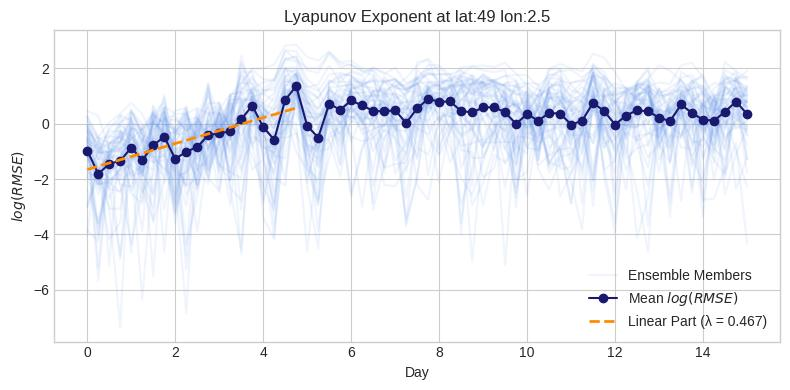

Estimated Lyapunov Exponent (λ): 0.467 days^-1


In [29]:
chaos_ifs_20190723.lyapunov_single_point(paris_latitude,paris_longitude)

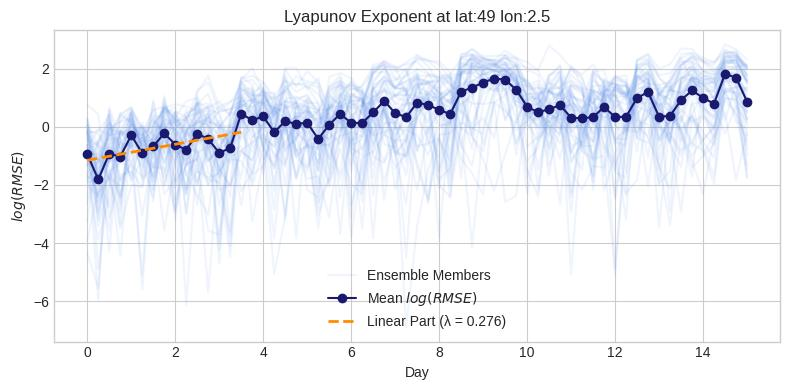

Estimated Lyapunov Exponent (λ): 0.276 days^-1


In [30]:
chaos_ifs_20200724.lyapunov_single_point(paris_latitude,paris_longitude)

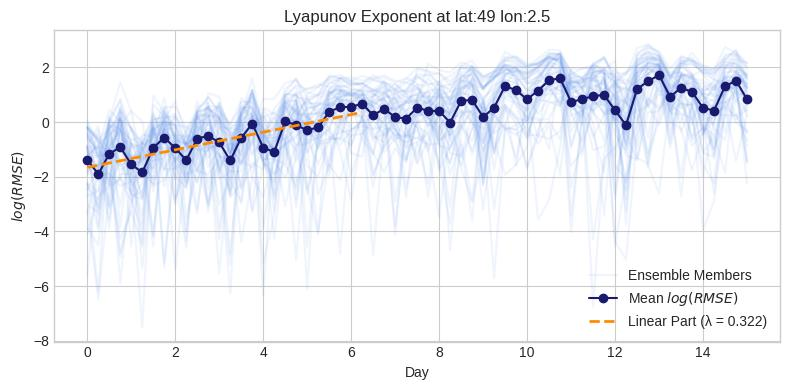

Estimated Lyapunov Exponent (λ): 0.322 days^-1


In [31]:
chaos_ifs_20220706.lyapunov_single_point(paris_latitude,paris_longitude)

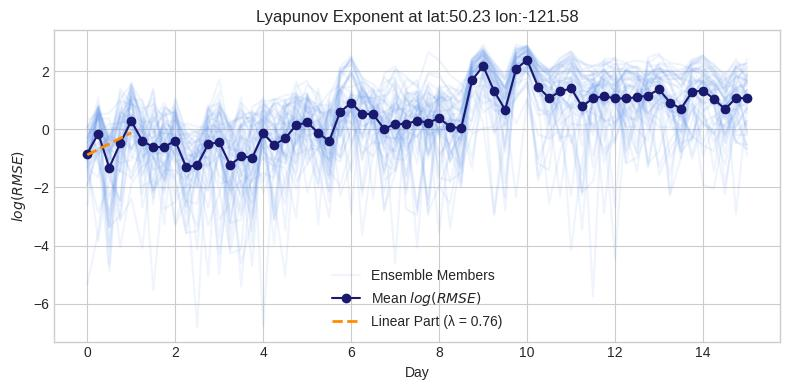

Estimated Lyapunov Exponent (λ): 0.76 days^-1


In [32]:
chaos_ifs_20210614.lyapunov_single_point(lytton_latitude,lytton_longitude)

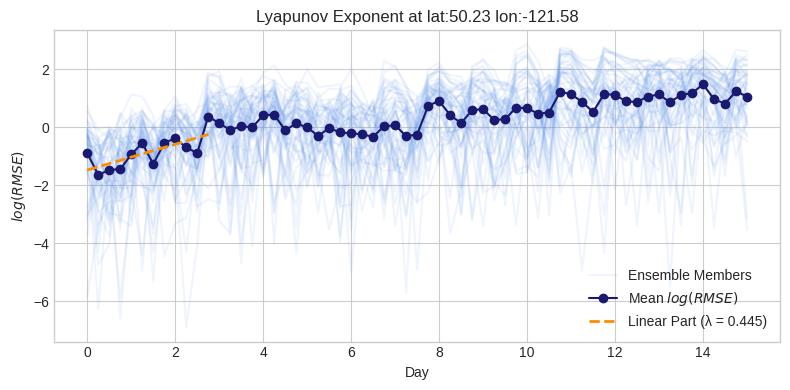

Estimated Lyapunov Exponent (λ): 0.445 days^-1


In [33]:
chaos_ifs_20210617.lyapunov_single_point(lytton_latitude,lytton_longitude)

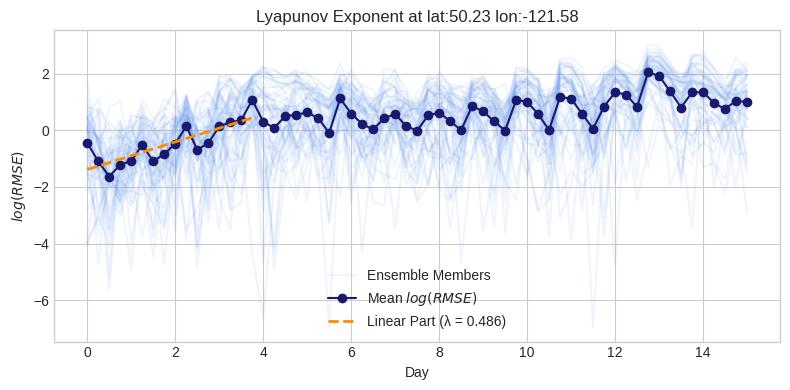

Estimated Lyapunov Exponent (λ): 0.486 days^-1


In [34]:
chaos_ifs_20210627.lyapunov_single_point(lytton_latitude,lytton_longitude)

#### IFS and AIFS

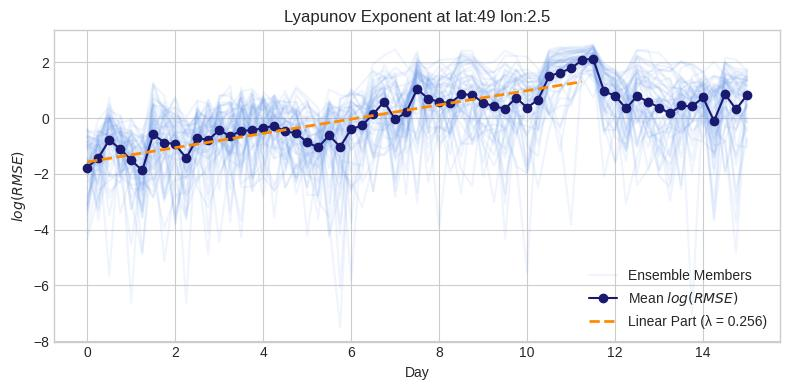

Estimated Lyapunov Exponent (λ): 0.256 days^-1


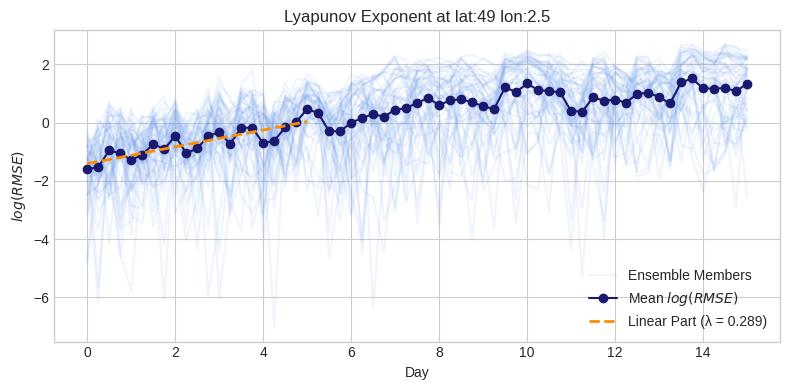

Estimated Lyapunov Exponent (λ): 0.289 days^-1


In [35]:
chaos_ifs_heat_august_2025.lyapunov_single_point(paris_latitude,paris_longitude)
chaos_aifs_heat_august_2025.lyapunov_single_point(paris_latitude,paris_longitude)

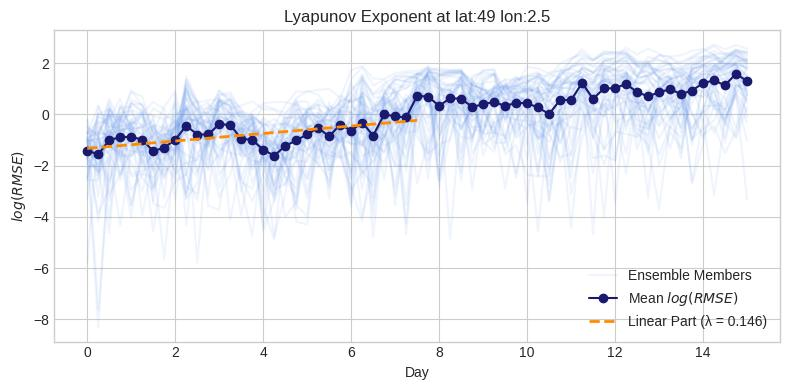

Estimated Lyapunov Exponent (λ): 0.146 days^-1


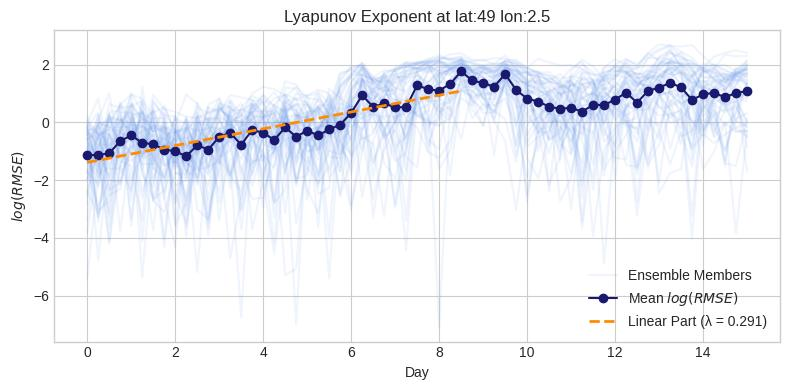

Estimated Lyapunov Exponent (λ): 0.291 days^-1


In [36]:
chaos_ifs_cold_spell_2025.lyapunov_single_point(paris_latitude,paris_longitude)
chaos_aifs_cold_spell_2025.lyapunov_single_point(paris_latitude,paris_longitude)

### Over an area

#### Only IFS

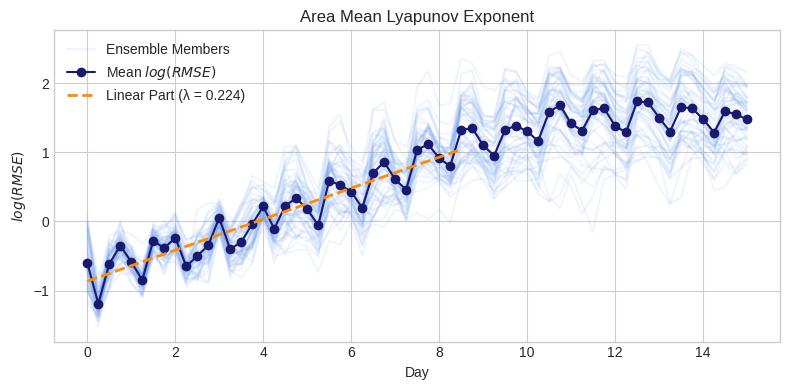

Estimated Lyapunov Exponent (λ): 0.224 days^-1


np.float64(0.224)

In [37]:
chaos_ifs_20150622.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

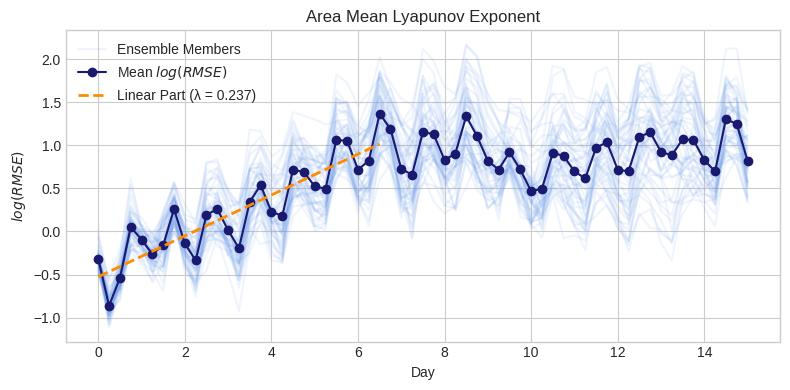

Estimated Lyapunov Exponent (λ): 0.237 days^-1


np.float64(0.237)

In [38]:
chaos_ifs_20170621.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

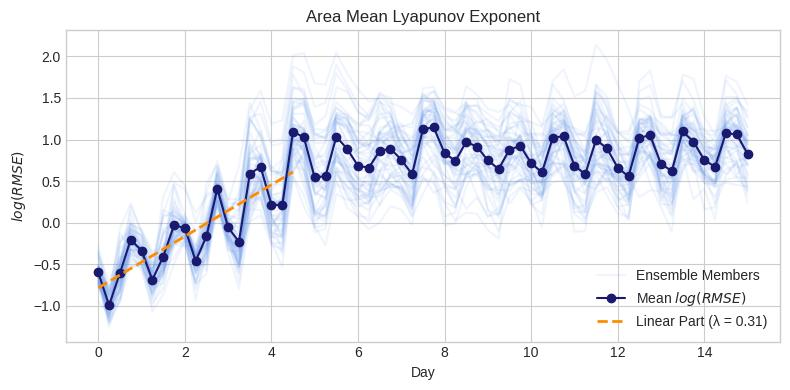

Estimated Lyapunov Exponent (λ): 0.31 days^-1


np.float64(0.31)

In [39]:
chaos_ifs_20190723.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

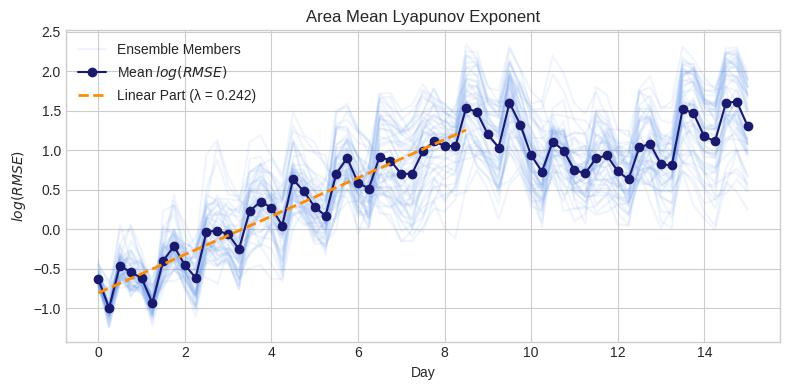

Estimated Lyapunov Exponent (λ): 0.242 days^-1


np.float64(0.242)

In [40]:
chaos_ifs_20200724.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

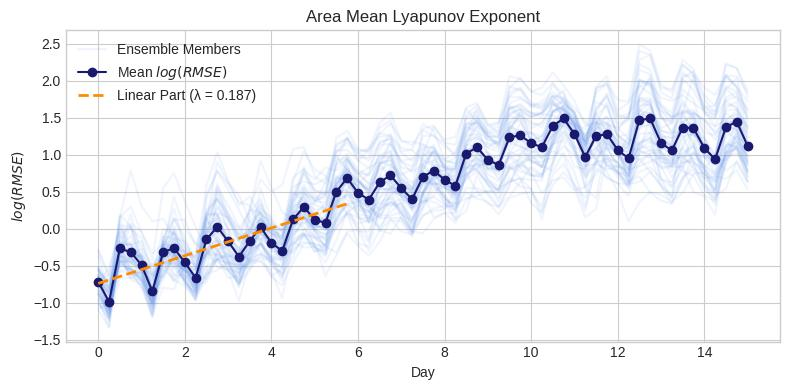

Estimated Lyapunov Exponent (λ): 0.187 days^-1


np.float64(0.187)

In [41]:
chaos_ifs_20220706.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

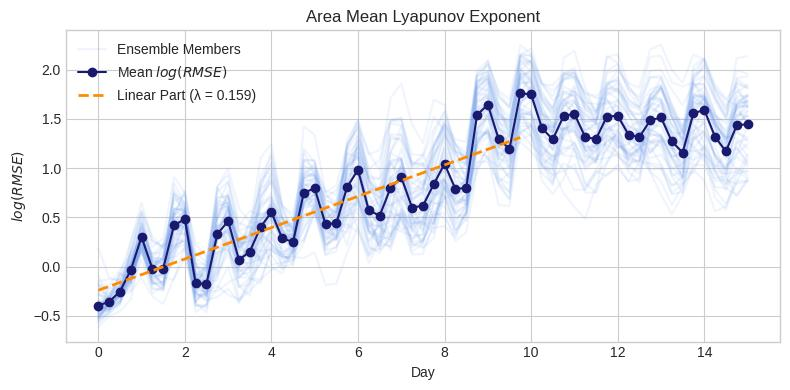

Estimated Lyapunov Exponent (λ): 0.159 days^-1


np.float64(0.159)

In [42]:
chaos_ifs_20210614.lyapunov_over_area(bc_latitude_bnd,bc_longitude_bnd)

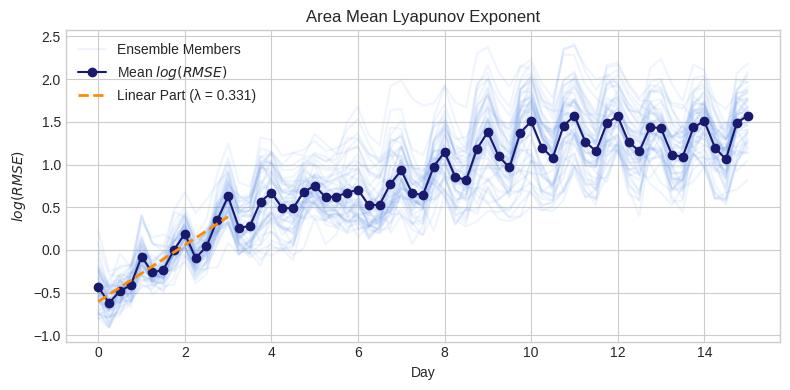

Estimated Lyapunov Exponent (λ): 0.331 days^-1


np.float64(0.331)

In [43]:
chaos_ifs_20210617.lyapunov_over_area(bc_latitude_bnd,bc_longitude_bnd)

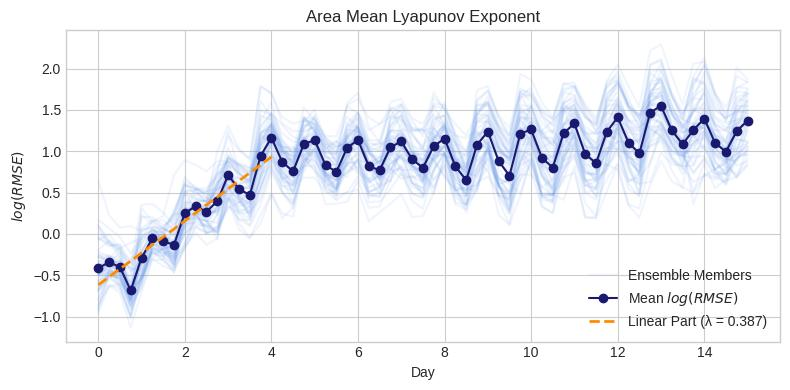

Estimated Lyapunov Exponent (λ): 0.387 days^-1


np.float64(0.387)

In [44]:
chaos_ifs_20210627.lyapunov_over_area(bc_latitude_bnd,bc_longitude_bnd)

#### IFS and AIFS

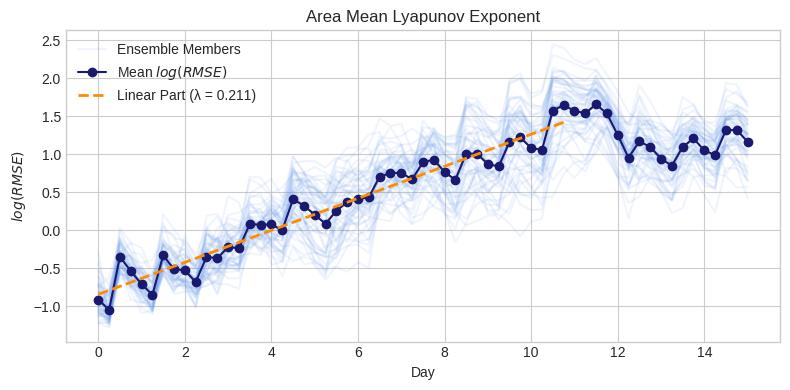

Estimated Lyapunov Exponent (λ): 0.211 days^-1


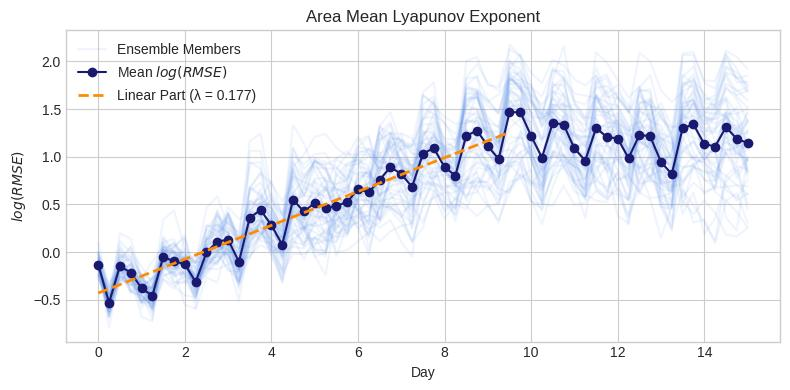

Estimated Lyapunov Exponent (λ): 0.177 days^-1


np.float64(0.177)

In [45]:
chaos_ifs_heat_august_2025.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)
chaos_aifs_heat_august_2025.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

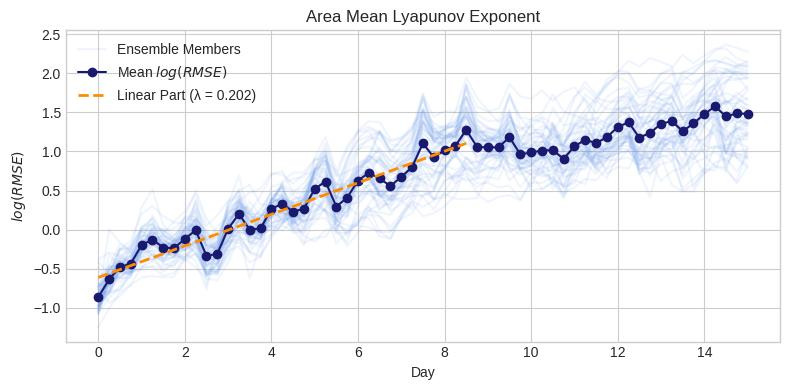

Estimated Lyapunov Exponent (λ): 0.202 days^-1


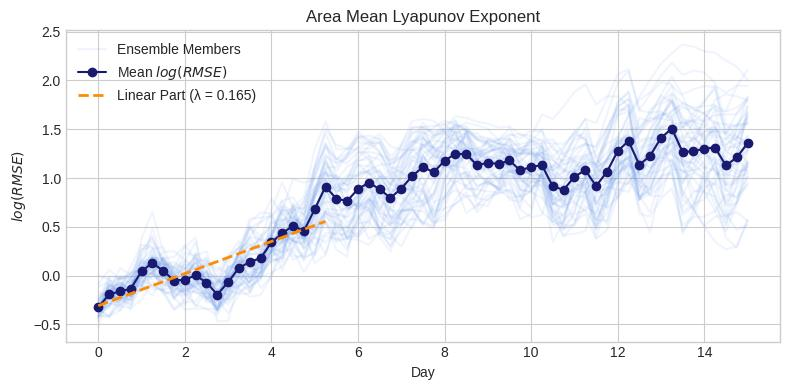

Estimated Lyapunov Exponent (λ): 0.165 days^-1


np.float64(0.165)

In [46]:
chaos_ifs_cold_spell_2025.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)
chaos_aifs_cold_spell_2025.lyapunov_over_area(france_latitude_bnd,france_longitude_bnd)

#### IFS and AIFS but pairwise

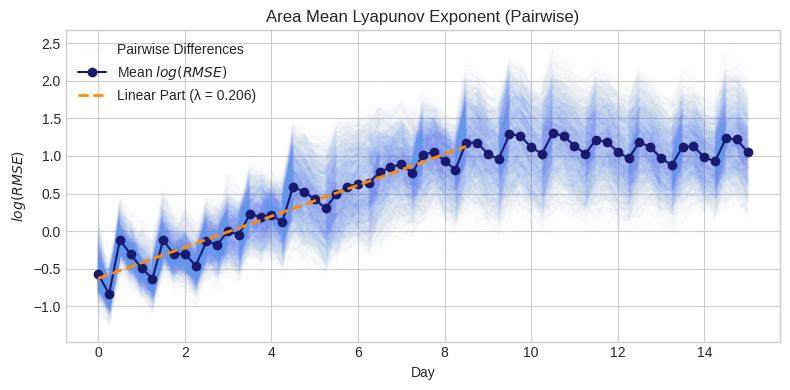

Estimated Lyapunov Exponent (λ): 0.206 days^-1


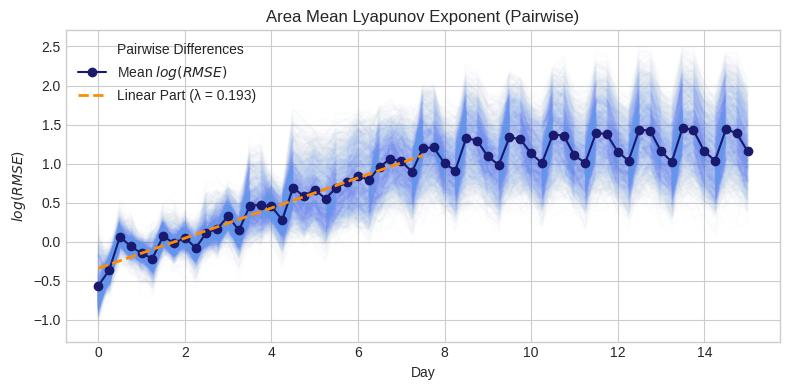

Estimated Lyapunov Exponent (λ): 0.193 days^-1


np.float64(0.193)

In [47]:
chaos_ifs_heat_august_2025.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd)
chaos_aifs_heat_august_2025.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd)

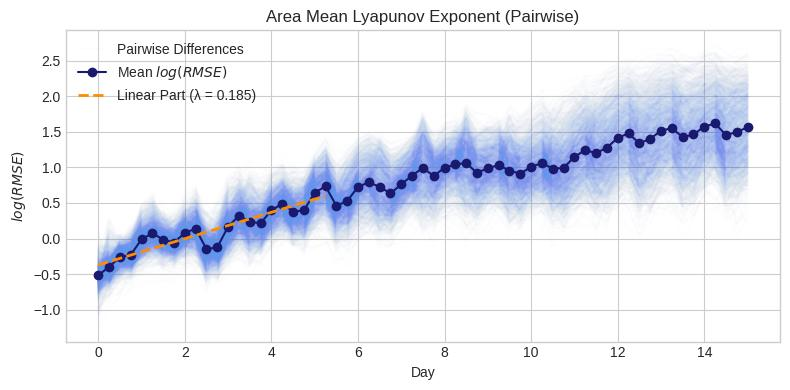

Estimated Lyapunov Exponent (λ): 0.185 days^-1


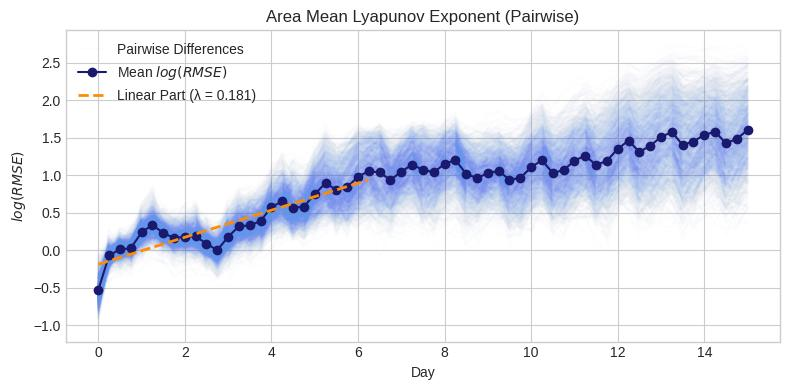

Estimated Lyapunov Exponent (λ): 0.181 days^-1


np.float64(0.181)

In [48]:
chaos_ifs_cold_spell_2025.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd)
chaos_aifs_cold_spell_2025.lyapunov_over_area_pairwise(france_latitude_bnd,france_longitude_bnd)

# Plot some maps

In [49]:
chaos_ifs_heat_august_2025.plot_nice_looking_animation(france_latitude_bnd, france_longitude_bnd,filename="test1.gif")

In [50]:
chaos_ifs_heat_august_2025.plot_nice_looking_animation_ortho(france_latitude_bnd, france_longitude_bnd,filename="test2.gif")